In [3]:
import random
import pandas as pd

random.seed(42)

rows = []

for i in range(100):      # Exactly 100 records

    student_id = i + 1

    age = random.randint(20,24)

    gender = random.choice(["Male","Female"])

    cgpa = round(random.uniform(5.5,9.8),2)

    # Base skill depends on CGPA
    base = int((cgpa-5.5)*2.2)

    programming = max(1,min(10,base+random.randint(0,2)))
    dsa = max(1,min(10,base+random.randint(0,2)))
    dbms = max(1,min(10,base+random.randint(-1,2)))
    os = max(1,min(10,base+random.randint(-1,2)))
    cn = max(1,min(10,base+random.randint(-1,2)))

    python = max(1,min(10,programming+random.randint(-1,1)))
    java = max(1,min(10,programming+random.randint(-1,1)))
    web = max(1,min(10,base+random.randint(-1,2)))

    ai = max(1,min(10,base+random.randint(-1,2)))
    cloud = max(1,min(10,base+random.randint(-1,2)))
    devops = max(1,min(10,base+random.randint(-1,2)))
    cyber = max(1,min(10,base+random.randint(-1,2)))

    communication = max(1,min(10,base+random.randint(-1,2)))
    aptitude = max(1,min(10,base+random.randint(-1,2)))
    teamwork = random.randint(5,10)

    internship = "Yes" if programming>=7 else random.choice(["Yes","No"])

    certifications = random.randint(0,5)

    projects = random.randint(1,5)

    training = "Yes" if aptitude>=7 else random.choice(["Yes","No"])

    # Employability Score
    score = (
        cgpa*10 +
        programming*6 +
        dsa*6 +
        communication*5 +
        aptitude*5 +
        teamwork*3 +
        cloud*2 +
        ai*2 +
        certifications*3 +
        projects*3
    )

    if internship=="Yes":
        score += 10

    if training=="Yes":
        score += 8

    # Target Class
    if score >= 180:
        employability = "High"
    elif score >= 140:
        employability = "Medium"
    else:
        employability = "Low"

    rows.append([
        student_id,
        age,
        gender,
        cgpa,
        programming,
        dsa,
        dbms,
        os,
        cn,
        python,
        java,
        web,
        ai,
        cloud,
        devops,
        cyber,
        communication,
        aptitude,
        teamwork,
        internship,
        certifications,
        projects,
        training,
        employability
    ])

columns = [
    "StudentID",
    "Age",
    "Gender",
    "CGPA",
    "Programming",
    "DSA",
    "DBMS",
    "OS",
    "CN",
    "Python",
    "Java",
    "WebDevelopment",
    "AI_ML",
    "Cloud",
    "DevOps",
    "CyberSecurity",
    "Communication",
    "Aptitude",
    "Teamwork",
    "Internship",
    "Certifications",
    "Projects",
    "PlacementTraining",
    "Employability"
]

df = pd.DataFrame(rows, columns=columns)

print(df.head())

print("\nClass Distribution:")
print(df["Employability"].value_counts())

df.to_excel("CSE_Employability_Dataset.xlsx", index=False)

print("\nDataset saved successfully.")

   StudentID  Age  Gender  CGPA  Programming  DSA  DBMS  OS  CN  Python  ...  \
0          1   20    Male  8.69            7    7     7   6   6       8  ...   
1          2   23    Male  7.43            5    4     4   6   5       5  ...   
2          3   23    Male  7.87            7    7     6   5   4       6  ...   
3          4   22  Female  6.40            2    3     1   1   1       1  ...   
4          5   24  Female  6.41            3    3     4   2   3       2  ...   

   DevOps  CyberSecurity  Communication  Aptitude  Teamwork  Internship  \
0       7              7              6         7        10         Yes   
1       3              6              3         5         7          No   
2       5              4              7         6         8         Yes   
3       2              1              1         1         7          No   
4       3              2              2         4         5         Yes   

   Certifications  Projects  PlacementTraining Employability  
0    

In [4]:
from google.colab import files

files.download("CSE_Employability_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

load

In [5]:
import pandas as pd

df = pd.read_excel("CSE_Employability_Dataset.xlsx")

df.head()

,StudentID,Age,Gender,CGPA,Programming,DSA,DBMS,OS,CN,Python,...,DevOps,CyberSecurity,Communication,Aptitude,Teamwork,Internship,Certifications,Projects,PlacementTraining,Employability
0,1,20,Male,8.69,7,7,7,6,6,8,...,7,7,6,7,10,Yes,5,5,Yes,High
1,2,23,Male,7.43,5,4,4,6,5,5,...,3,6,3,5,7,No,0,4,Yes,High
2,3,23,Male,7.87,7,7,6,5,4,6,...,5,4,7,6,8,Yes,5,3,Yes,High
3,4,22,Female,6.40,2,3,1,1,1,1,...,2,1,1,1,7,No,2,1,Yes,Medium
4,5,24,Female,6.41,3,3,4,2,3,2,...,3,2,2,4,5,Yes,0,2,Yes,High


Data Preprocessing

In [6]:
# Check Missing Values
print(df.isnull().sum())

# Remove Duplicates
df = df.drop_duplicates()

# Encode Categorical Variables
df["Gender"] = df["Gender"].map({"Male":0,"Female":1})

df["Internship"] = df["Internship"].map({"No":0,"Yes":1})

df["PlacementTraining"] = df["PlacementTraining"].map({"No":0,"Yes":1})

df["Employability"] = df["Employability"].map({
    "Low":0,
    "Medium":1,
    "High":2
})

print(df.head())

StudentID            0
Age                  0
Gender               0
CGPA                 0
Programming          0
DSA                  0
DBMS                 0
OS                   0
CN                   0
Python               0
Java                 0
WebDevelopment       0
AI_ML                0
Cloud                0
DevOps               0
CyberSecurity        0
Communication        0
Aptitude             0
Teamwork             0
Internship           0
Certifications       0
Projects             0
PlacementTraining    0
Employability        0
dtype: int64
   StudentID  Age  Gender  CGPA  Programming  DSA  DBMS  OS  CN  Python  ...  \
0          1   20       0  8.69            7    7     7   6   6       8  ...   
1          2   23       0  7.43            5    4     4   6   5       5  ...   
2          3   23       0  7.87            7    7     6   5   4       6  ...   
3          4   22       1  6.40            2    3     1   1   1       1  ...   
4          5   24       1  6.41    

Feature Selection

In [7]:
# Remove unnecessary columns

X = df.drop(["StudentID","Employability"], axis=1)

y = df["Employability"]

print("Selected Features")

print(X.columns)

Selected Features
Index(['Age', 'Gender', 'CGPA', 'Programming', 'DSA', 'DBMS', 'OS', 'CN',
       'Python', 'Java', 'WebDevelopment', 'AI_ML', 'Cloud', 'DevOps',
       'CyberSecurity', 'Communication', 'Aptitude', 'Teamwork', 'Internship',
       'Certifications', 'Projects', 'PlacementTraining'],
      dtype='object')


Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80, 22)
(20, 22)


Model Training

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train,y_train)

print("Model Trained Successfully")

Model Trained Successfully


Feature Importance

In [10]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

              Feature  Importance
13             DevOps    0.181277
2                CGPA    0.096083
3         Programming    0.092912
16           Aptitude    0.086808
8              Python    0.086320
4                 DSA    0.061926
11              AI_ML    0.061047
12              Cloud    0.055458
6                  OS    0.052095
9                Java    0.046523
15      Communication    0.027889
5                DBMS    0.025367
19     Certifications    0.020944
10     WebDevelopment    0.020151
14      CyberSecurity    0.019420
0                 Age    0.016016
7                  CN    0.012948
20           Projects    0.011138
17           Teamwork    0.009127
18         Internship    0.006933
21  PlacementTraining    0.005394
1              Gender    0.004227


Model Evaluation

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9

Confusion Matrix
[[ 0  1  0]
 [ 0  4  0]
 [ 0  1 14]]

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         4
           2       1.00      0.93      0.97        15

    accuracy                           0.90        20
   macro avg       0.56      0.64      0.59        20
weighted avg       0.88      0.90      0.88        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

<Figure size 600x500 with 0 Axes>

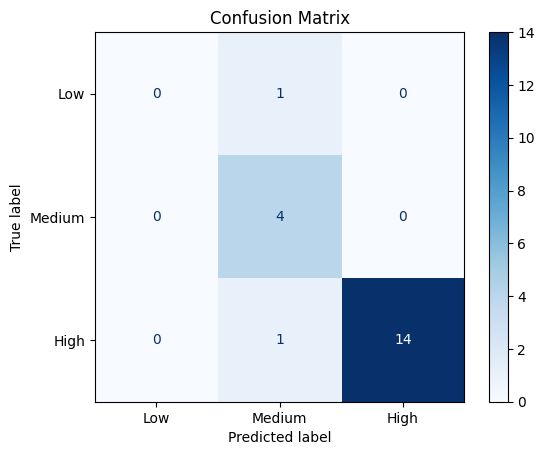

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low","Medium","High"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

Actual vs Predicted Employability (Bar Chart)

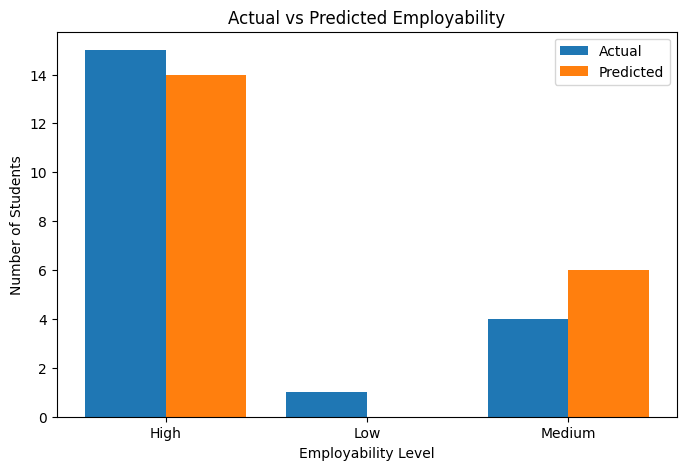

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison = comparison.replace({
    0:"Low",
    1:"Medium",
    2:"High"
})

actual_count = comparison["Actual"].value_counts().sort_index()

predicted_count = comparison["Predicted"].value_counts().sort_index()

labels = ["High","Low","Medium"]

actual = [
    actual_count.get("High",0),
    actual_count.get("Low",0),
    actual_count.get("Medium",0)
]

predicted = [
    predicted_count.get("High",0),
    predicted_count.get("Low",0),
    predicted_count.get("Medium",0)
]

x = range(len(labels))

plt.figure(figsize=(8,5))

plt.bar([i-0.2 for i in x], actual, width=0.4, label="Actual")

plt.bar([i+0.2 for i in x], predicted, width=0.4, label="Predicted")

plt.xticks(x, labels)

plt.xlabel("Employability Level")

plt.ylabel("Number of Students")

plt.title("Actual vs Predicted Employability")

plt.legend()

plt.show()

Feature Importance (Horizontal Bar Chart)

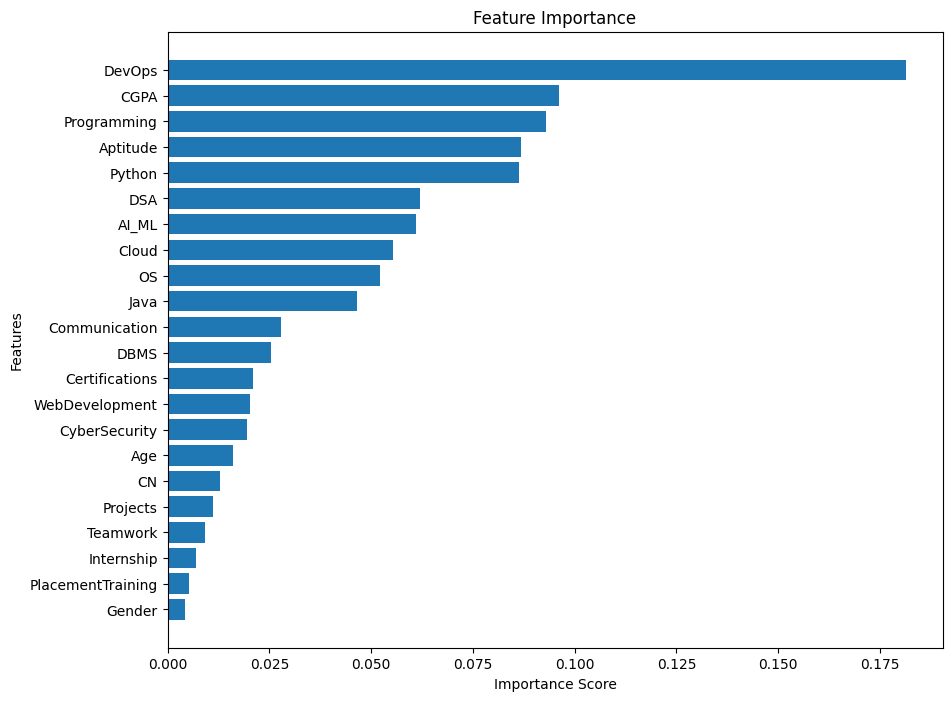

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Feature Importance")

plt.show()

Accuracy Bar Chart

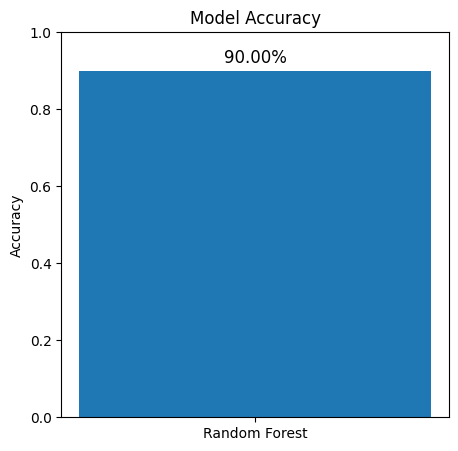

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(5,5))

plt.bar(["Random Forest"], [accuracy])

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Model Accuracy")

plt.text(
    0,
    accuracy+0.02,
    f"{accuracy*100:.2f}%",
    ha="center",
    fontsize=12
)

plt.show()